# Cellpose Segmentation Comparison: 3D vs Stitched vs Per-Plane

Compares three segmentation approaches:
1. **Cellpose-3D**: True 3D segmentation using all orthogonal views
2. **Cellpose-Stitched**: 2D per plane with IoU-based cross-Z stitching
3. **Cellpose-PerPlane**: 2D per plane via Suite2p (no cross-Z info)

In [1]:
!uv pip install ../../../mbo_utilities/

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 157 packages in 428ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 1.07s
Uninstalled 1 package in 8ms
Installed 1 package in 18ms
 ~ mbo-utilities==2.3.0 (from file:///C:/Users/RBO/repos/mbo_utilities)


In [2]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from mbo_utilities import imread, imwrite
from mbo_utilities.file_io import get_files
from cellpose import models, core, io, metrics
import lbm_suite2p_python as lsp

io.logger_setup()
print(f"GPU available: {core.use_gpu()}")

2025-12-03 23:35:33,684 [INFO] WRITING LOG OUTPUT TO C:\Users\RBO\.cellpose\run.log
2025-12-03 23:35:33,684 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.12.9 
torch version:  	2.9.1+cu126
2025-12-03 23:35:33,753 [INFO] ** TORCH CUDA version installed and working. **
GPU available: True


## Configuration

In [3]:
# Input/output paths
INPUT_PATH = Path(r"D:\raw_scanimage_tiffs")
OUTPUT_DIR = INPUT_PATH / "cellpose_comparison"
OUTPUT_DIR.mkdir(exist_ok=True)

# Cellpose parameters (shared across methods)
DIAMETER = 6
FLOW_THRESHOLD = 0.4
CELLPROB_THRESHOLD = 0.0
STITCH_THRESHOLD = 0.5

# Anisotropy calculation:
# Physical: Z=15µm, XY=2µm -> true anisotropy = 15/2 = 7.5
# BUT Cellpose multiplies anisotropy by (30/diameter) internally!
# So we need: anisotropy * (30/DIAMETER) = 7.5
# Therefore: anisotropy = 7.5 / (30/DIAMETER) = 7.5 * DIAMETER / 30
PHYSICAL_ANISOTROPY = 15 / 2  # 7.5
ANISOTROPY = PHYSICAL_ANISOTROPY * DIAMETER / 30  # = 1.5

# Force recompute
FORCE = True

## Load Data

In [4]:
# Load or create zarr cache
zarr_path = OUTPUT_DIR / "volume.zarr"

if zarr_path.exists() and not FORCE:
    print(f"Loading cached zarr...")
    volume = imread(zarr_path)
else:
    print(f"Loading raw data from {INPUT_PATH}...")
    volume = imread(INPUT_PATH)
    imwrite(volume, zarr_path, ext=".zarr", overwrite=True)

# Get dimensions (TZYX)
n_frames, n_planes, Ly, Lx = volume.shape
print(f"Shape: {volume.shape} | Frames: {n_frames}, Planes: {n_planes}, Size: {Ly}x{Lx}")

Loading raw data from D:\raw_scanimage_tiffs...


Counting frames:   0%|          | 0/6 [00:00<?, ?it/s]

Saving plane01_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane02_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane03_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

...

Saving plane11_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane12_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane13_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane14_stitched.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Shape: (1163, 14, 448, 448) | Frames: 1163, Planes: 14, Size: 448x448


In [5]:
# Create max projection over time -> (Z, Y, X)
max_proj_path = OUTPUT_DIR / "max_proj_zstack.tif"

if max_proj_path.exists() and not FORCE:
    max_proj_3d = tifffile.imread(max_proj_path)
else:
    print("Computing max projection...")
    max_proj_3d = np.max(volume, axis=0)
    tifffile.imwrite(max_proj_path, max_proj_3d)

print(f"Max projection shape: {max_proj_3d.shape}")

Computing max projection...


Computing max:   0%|          | 0/11 [00:00<?, ?it/s]

Max projection shape: (14, 448, 448)


## Run All Three Methods

In [6]:
# Initialize Cellpose model
model = models.CellposeModel(gpu=core.use_gpu())

# Storage for results
results = {}
METHODS = ["3D", "Stitched", "PerPlane"]

2025-12-03 23:36:14,109 [INFO] ** TORCH CUDA version installed and working. **
2025-12-03 23:36:14,110 [INFO] ** TORCH CUDA version installed and working. **
2025-12-03 23:36:14,111 [INFO] >>>> using GPU (CUDA)
2025-12-03 23:36:15,269 [INFO] >>>> loading model C:\Users\RBO\.cellpose\models\cpsam


In [7]:
# Method 1: Cellpose-3D
masks_path = OUTPUT_DIR / "masks_3d.tif"

if masks_path.exists() and not FORCE:
    print("Loading cached 3D masks...")
    masks_3d = tifffile.imread(masks_path)
    results["3D"] = {"masks": masks_3d, "time": None}
else:
    print(f"Running Cellpose-3D ({n_planes} XY + {Ly} ZY + {Lx} ZX planes)...")
    t0 = time.perf_counter()
    # Note: resample=False to match other methods and avoid potential bugs
    masks_3d, _, _ = model.eval(
        max_proj_3d, batch_size=32, diameter=DIAMETER,
        flow_threshold=FLOW_THRESHOLD, cellprob_threshold=CELLPROB_THRESHOLD,
        do_3D=True, z_axis=0, anisotropy=ANISOTROPY,
        resample=False
    )
    elapsed = time.perf_counter() - t0
    tifffile.imwrite(masks_path, masks_3d.astype(np.uint16))
    results["3D"] = {"masks": masks_3d, "time": elapsed}
    print(f"Done in {elapsed:.1f}s")

print(f"Cellpose-3D: {masks_3d.max()} cells")

Running Cellpose-3D (14 XY + 448 ZY + 448 ZX planes)...
2025-12-03 23:36:16,490 [INFO] resizing 3D image with anisotropy=7.5
2025-12-03 23:36:20,189 [INFO] running YX: 105 planes of size (2240, 2240)
2025-12-03 23:45:37,562 [INFO] 100%|##########| 105/105 [09:17<00:00,  5.31s/it]
2025-12-03 23:45:40,756 [INFO] running ZY: 2240 planes of size (105, 2240)
2025-12-04 00:03:45,238 [INFO] 100%|##########| 1120/1120 [18:04<00:00,  1.03it/s]
2025-12-04 00:03:48,540 [INFO] running ZX: 2240 planes of size (105, 2240)
2025-12-04 00:20:35,008 [INFO] 100%|##########| 1120/1120 [16:46<00:00,  1.11it/s]
2025-12-04 00:20:51,598 [INFO] network run in 2675.11s
2025-12-04 00:21:03,650 [WARNING] Resizing is deprecated in v4.0.1+
2025-12-04 00:21:07,741 [INFO] masks created in 15.85s
Done in 2696.0s
Cellpose-3D: 94 cells


In [8]:
# Method 2: Cellpose-Stitched
masks_path = OUTPUT_DIR / "masks_stitched.tif"

if masks_path.exists() and not FORCE:
    print("Loading cached stitched masks...")
    masks_stitched = tifffile.imread(masks_path)
    results["Stitched"] = {"masks": masks_stitched, "time": None}
else:
    print(f"Running Cellpose-Stitched ({n_planes} planes + IoU stitching)...")
    t0 = time.perf_counter()
    # Note: resample=False avoids a Cellpose bug with diameter + stitch_threshold
    masks_stitched, _, _ = model.eval(
        max_proj_3d, batch_size=32, diameter=DIAMETER,
        flow_threshold=FLOW_THRESHOLD, cellprob_threshold=CELLPROB_THRESHOLD,
        do_3D=False, stitch_threshold=STITCH_THRESHOLD, z_axis=0,
        resample=False
    )
    elapsed = time.perf_counter() - t0
    tifffile.imwrite(masks_path, masks_stitched.astype(np.uint16))
    results["Stitched"] = {"masks": masks_stitched, "time": elapsed}
    print(f"Done in {elapsed:.1f}s")

print(f"Cellpose-Stitched: {masks_stitched.max()} cells")

Running Cellpose-Stitched (14 planes + IoU stitching)...
2025-12-04 00:22:17,680 [INFO] 100%|##########| 14/14 [01:05<00:00,  4.65s/it]
2025-12-04 00:22:17,697 [INFO] network run in 65.10s
2025-12-04 00:22:22,287 [INFO] 100%|##########| 14/14 [00:04<00:00,  3.05it/s]
2025-12-04 00:22:22,287 [INFO] stitching 14 planes using stitch_threshold=0.500 to make 3D masks


100%|██████████| 13/13 [00:01<00:00,  7.31it/s]


2025-12-04 00:22:24,607 [INFO] masks created in 6.91s
Done in 73.3s
Cellpose-Stitched: 221 cells


In [9]:
# Method 3: Cellpose-PerPlane (via Suite2p pipeline)
s2p_dir = OUTPUT_DIR / "suite2p_perplane"
masks_path = OUTPUT_DIR / "masks_perplane.tif"

if masks_path.exists() and not FORCE:
    print("Loading cached per-plane masks...")
    masks_perplane = tifffile.imread(masks_path)
    results["PerPlane"] = {"masks": masks_perplane, "time": None}
else:
    print(f"Running Cellpose-PerPlane via Suite2p ({n_planes} independent planes)...")
    t0 = time.perf_counter()

    # Use same parameters as direct Cellpose methods
    # anatomical_only=4 uses max_proj (same as our max_proj_3d input)
    # spatial_hp_cp=0 disables high-pass filtering to match direct Cellpose
    ops_files = lsp.pipeline(
        INPUT_PATH, save_path=s2p_dir,
        ops={
            "anatomical_only": 4,  # Use max_proj (not meanImgE)
            "diameter": DIAMETER,
            "cellprob_threshold": CELLPROB_THRESHOLD,
            "flow_threshold": FLOW_THRESHOLD,
            "spatial_hp_cp": 0,  # No high-pass to match direct Cellpose
        },
        keep_reg=False, keep_raw=False
    )
    elapsed = time.perf_counter() - t0

    # Reconstruct masks from stat files
    masks_list = []
    for ops_file in sorted(get_files(s2p_dir, "ops.npy", max_depth=2)):
        plane_dir = Path(ops_file).parent
        ops = np.load(ops_file, allow_pickle=True).item()
        stat = np.load(plane_dir / "stat.npy", allow_pickle=True) if (plane_dir / "stat.npy").exists() else []

        mask = np.zeros((ops.get("Ly", Ly), ops.get("Lx", Lx)), dtype=np.uint16)
        for j, s in enumerate(stat):
            ypix, xpix = s["ypix"], s["xpix"]
            valid = (ypix >= 0) & (ypix < mask.shape[0]) & (xpix >= 0) & (xpix < mask.shape[1])
            mask[ypix[valid], xpix[valid]] = j + 1
        masks_list.append(mask)

    masks_perplane = np.stack(masks_list, axis=0)
    tifffile.imwrite(masks_path, masks_perplane)
    results["PerPlane"] = {"masks": masks_perplane, "time": elapsed}
    print(f"Done in {elapsed:.1f}s")

print(f"Cellpose-PerPlane: {masks_perplane.max()} cells")

Running Cellpose-PerPlane via Suite2p (14 independent planes)...
Loading input data...
  Input: D:\raw_scanimage_tiffs


Counting frames:   0%|          | 0/6 [00:00<?, ?it/s]

  Loaded as: MboRawArray

Dataset info:
  Shape: (1163, 14, 448, 448)
  Frames: 1163
  Planes: 14
  Dimensions: 448 x 448
  Phase correction: True
  FFT subpixel: False
  Frame rate: 17.07 Hz
  ROIs: 2
Importing suite2p packages...

Processing plan:
  Planes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  Output: D:\raw_scanimage_tiffs\cellpose_comparison\suite2p_perplane

Processing plane 1/14
  Skipping plane01_stitched: already complete
Plotting results for 35 accepted / 5 rejected ROIs

Processing plane 2/14
  Skipping plane02_stitched: already complete
Plotting results for 53 accepted / 8 rejected ROIs

Processing plane 3/14
  Skipping plane03_stitched: already complete
Plotting results for 63 accepted / 9 rejected ROIs

Processing plane 4/14
  Skipping plane04_stitched: already complete
Plotting results for 61 accepted / 21 rejected ROIs

Processing plane 5/14
  Skipping plane05_stitched: already complete
Plotting results for 64 accepted / 12 rejected ROIs

Processing plane 6/

## Compute Statistics

In [10]:
def get_cell_sizes(masks):
    """Get pixel count for each unique cell label."""
    labels = np.unique(masks)
    labels = labels[labels > 0]
    return np.array([np.sum(masks == lbl) for lbl in labels])

def cells_per_plane(masks):
    """Count unique cell labels in each Z-plane."""
    if masks.ndim == 2:
        return [len(np.unique(masks)) - 1]
    return [len(np.unique(masks[z])) - 1 for z in range(masks.shape[0])]

# Compute stats for all methods
for name in METHODS:
    masks = results[name]["masks"]
    results[name]["n_cells"] = int(masks.max())
    results[name]["sizes"] = get_cell_sizes(masks)
    results[name]["per_plane"] = cells_per_plane(masks)

# Print summary
print(f"{'Method':<15} {'Cells':>8} {'Med.Size':>10} {'Time':>10}")
print("-" * 45)
for name in METHODS:
    r = results[name]
    t = f"{r['time']:.1f}s" if r['time'] else "cached"
    print(f"{name:<15} {r['n_cells']:>8} {np.median(r['sizes']):>10.0f} {t:>10}")

Method             Cells   Med.Size       Time
---------------------------------------------
3D                    94         22    2696.0s
Stitched             221         89      73.3s
PerPlane             155        386      58.9s


## Visual Comparison: Masks

In [11]:
def mask_overlay(img, mask, alpha=0.5):
    """Create RGB overlay of colored masks on grayscale image."""
    from cellpose.plot import mask_rgb
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([img_norm] * 3, axis=-1)
    if mask.max() > 0:
        colors = mask_rgb(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]
    return np.clip(rgb, 0, 1)

# Colors for each method
COLORS = {"3D": "tab:blue", "Stitched": "tab:orange", "PerPlane": "tab:green"}

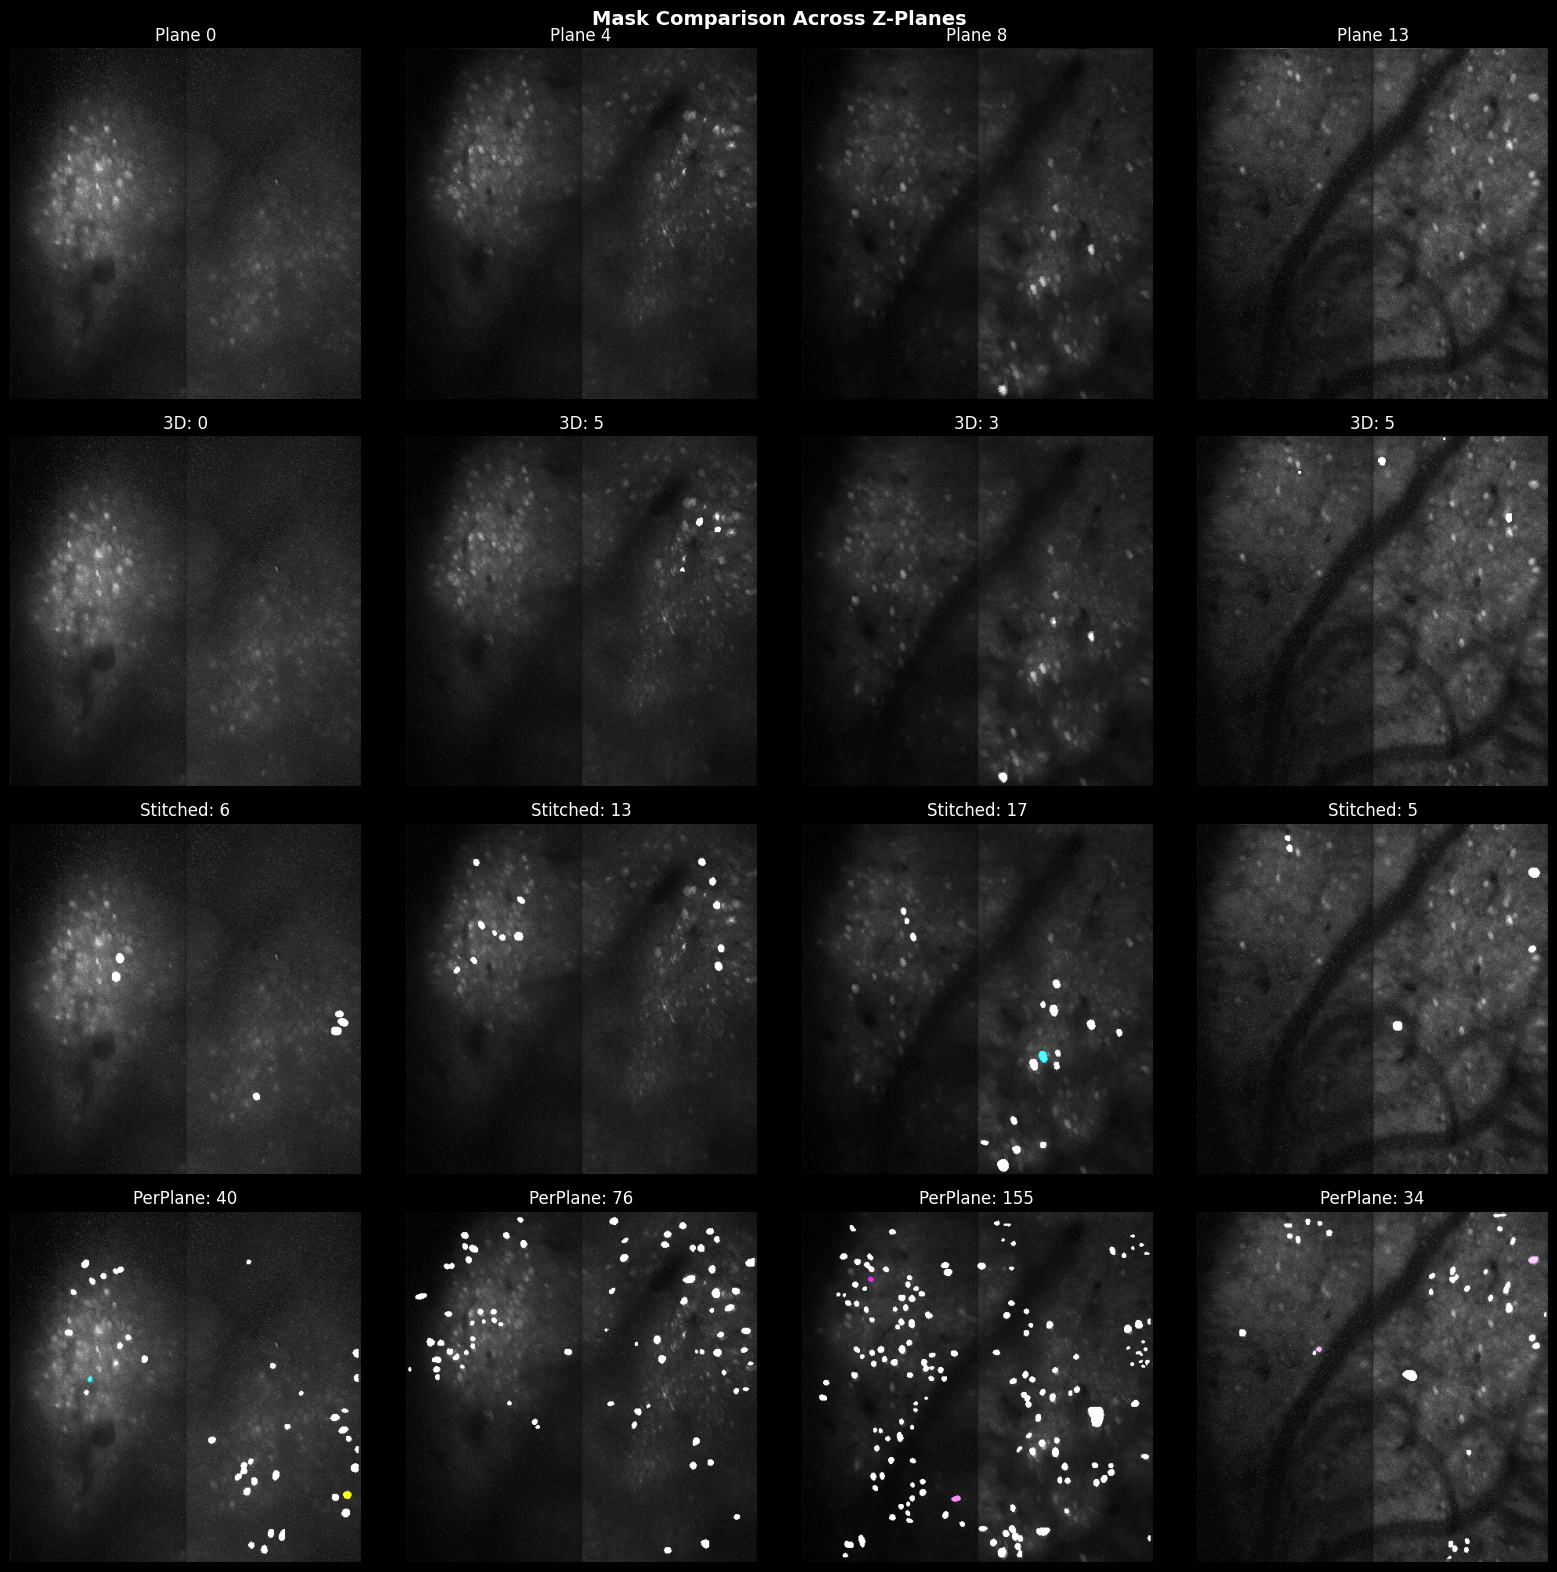

In [12]:
# Side-by-side mask comparison across planes
n_show = min(4, n_planes)
plane_indices = np.linspace(0, n_planes - 1, n_show, dtype=int)

fig, axes = plt.subplots(len(METHODS) + 1, n_show, figsize=(4 * n_show, 4 * (len(METHODS) + 1)))

for col, z in enumerate(plane_indices):
    img = max_proj_3d[z]

    # Row 0: Raw image
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"Plane {z}")
    axes[0, col].axis("off")

    # Rows 1-3: Each method
    for row, name in enumerate(METHODS, 1):
        masks = results[name]["masks"]
        mask_plane = masks[z] if masks.ndim == 3 else masks
        n_in_plane = len(np.unique(mask_plane)) - 1

        axes[row, col].imshow(mask_overlay(img, mask_plane))
        axes[row, col].set_title(f"{name}: {n_in_plane}")
        axes[row, col].axis("off")

# Row labels
axes[0, 0].set_ylabel("Raw", fontsize=12)
for row, name in enumerate(METHODS, 1):
    axes[row, 0].set_ylabel(name, fontsize=12)

plt.suptitle("Mask Comparison Across Z-Planes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_masks.png", dpi=150)
plt.show()

## Cell Count Per Plane

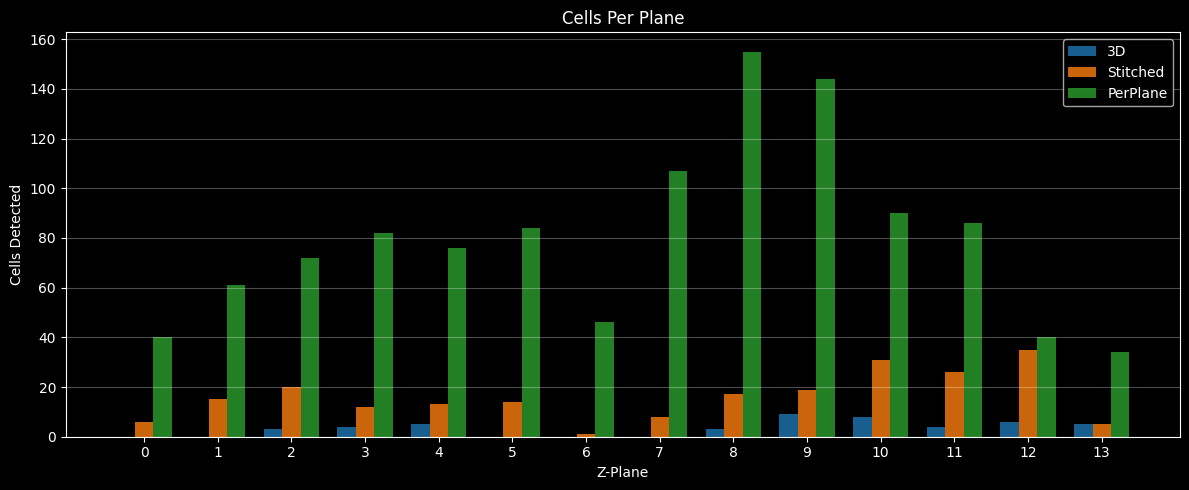

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(n_planes)
width = 0.25

for i, name in enumerate(METHODS):
    counts = results[name]["per_plane"]
    ax.bar(x + i * width, counts, width, label=name, color=COLORS[name], alpha=0.8)

ax.set_xlabel("Z-Plane")
ax.set_ylabel("Cells Detected")
ax.set_title("Cells Per Plane")
ax.set_xticks(x + width)
ax.set_xticklabels([str(i) for i in range(n_planes)])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_cells_per_plane.png", dpi=150)
plt.show()

## Cell Size Distribution

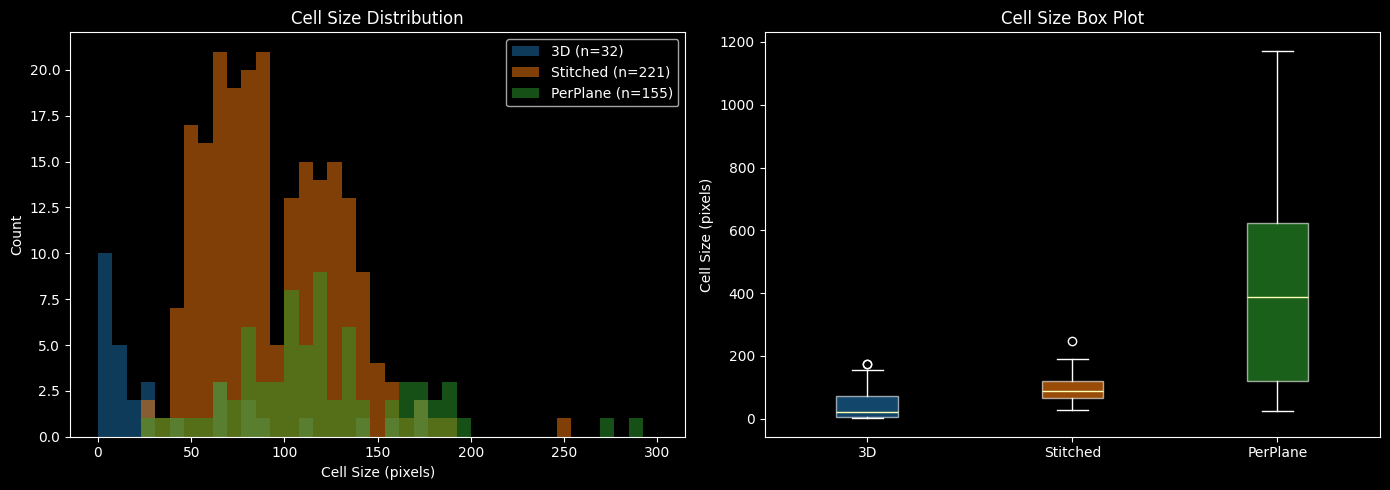

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
max_size = max(results[m]["sizes"].max() for m in METHODS)
bins = np.linspace(0, min(max_size, 300), 40)

for name in METHODS:
    sizes = results[name]["sizes"]
    ax.hist(sizes, bins=bins, alpha=0.5, label=f"{name} (n={len(sizes)})", color=COLORS[name])

ax.set_xlabel("Cell Size (pixels)")
ax.set_ylabel("Count")
ax.set_title("Cell Size Distribution")
ax.legend()

# Box plot
ax = axes[1]
data = [results[m]["sizes"] for m in METHODS]
bp = ax.boxplot(data, labels=METHODS, patch_artist=True)
for patch, name in zip(bp["boxes"], METHODS):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.6)
ax.set_ylabel("Cell Size (pixels)")
ax.set_title("Cell Size Box Plot")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_cell_sizes.png", dpi=150)
plt.show()

## Cross-Method IoU Agreement

In [15]:
def compute_best_ious(masks1, masks2):
    """Compute best IoU for each mask in masks1 vs masks2."""
    if masks1.shape != masks2.shape:
        return None
    ious, _ = metrics.mask_ious(masks1, masks2)
    if len(ious) == 0:
        return np.array([])
    return ious.max(axis=1) if ious.ndim > 1 else ious

# Compute pairwise IoUs
pairs = [("3D", "Stitched"), ("3D", "PerPlane"), ("Stitched", "PerPlane")]
iou_results = {}

for m1, m2 in pairs:
    ious = compute_best_ious(results[m1]["masks"], results[m2]["masks"])
    iou_results[f"{m1} vs {m2}"] = ious
    if ious is not None and len(ious) > 0:
        print(f"{m1} vs {m2}: median IoU = {np.median(ious):.3f}, {np.sum(ious > 0.5)}/{len(ious)} > 0.5")

3D vs Stitched: median IoU = 0.000, 0/94 > 0.5
3D vs PerPlane: median IoU = 0.000, 0/94 > 0.5
Stitched vs PerPlane: median IoU = 0.000, 3/221 > 0.5


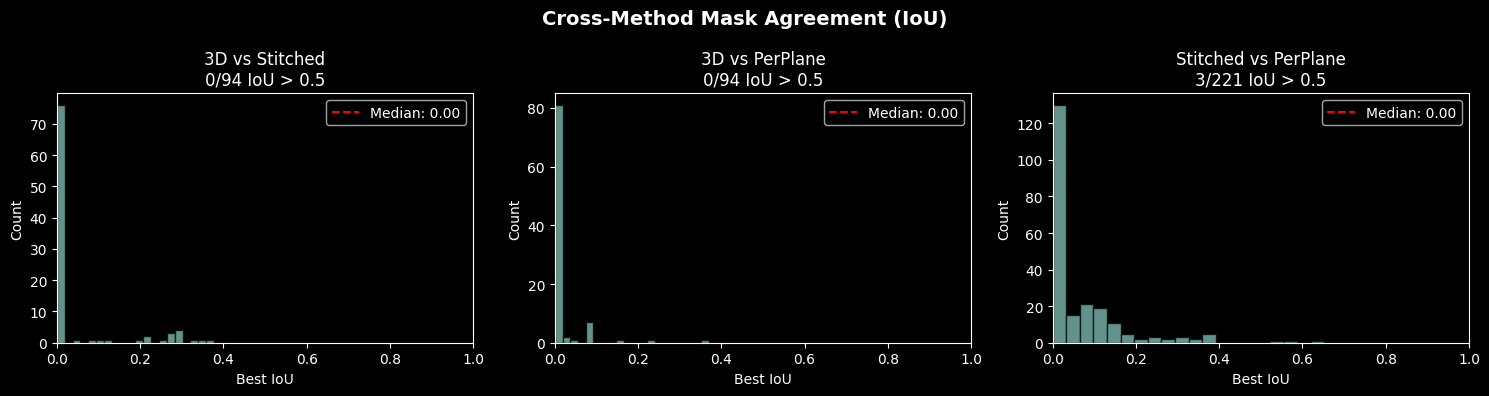

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (pair_name, ious) in zip(axes, iou_results.items()):
    if ious is not None and len(ious) > 0:
        ax.hist(ious, bins=20, alpha=0.7, edgecolor="black")
        ax.axvline(np.median(ious), color="red", linestyle="--", label=f"Median: {np.median(ious):.2f}")
        ax.set_title(f"{pair_name}\n{np.sum(ious > 0.5)}/{len(ious)} IoU > 0.5")
    else:
        ax.text(0.5, 0.5, "No overlap", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(pair_name)
    ax.set_xlabel("Best IoU")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
    ax.legend()

plt.suptitle("Cross-Method Mask Agreement (IoU)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_iou.png", dpi=150)
plt.show()

## Single-Plane Detail View

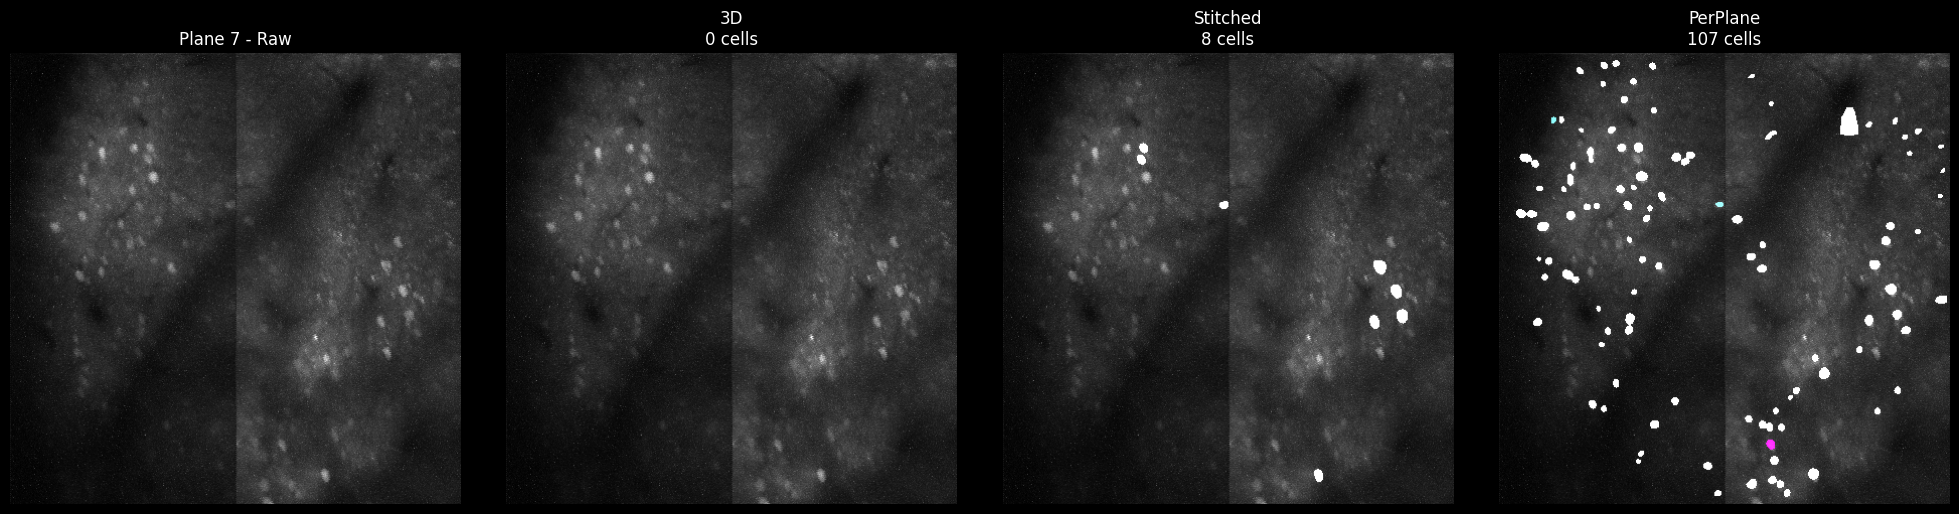

In [17]:
# Pick middle plane for detailed view
z = n_planes // 2
img = max_proj_3d[z]

fig, axes = plt.subplots(1, len(METHODS) + 1, figsize=(5 * (len(METHODS) + 1), 5))

# Raw image
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Plane {z} - Raw")
axes[0].axis("off")

# Each method
for ax, name in zip(axes[1:], METHODS):
    masks = results[name]["masks"]
    mask_plane = masks[z] if masks.ndim == 3 else masks
    n_cells = len(np.unique(mask_plane)) - 1

    ax.imshow(mask_overlay(img, mask_plane))
    ax.set_title(f"{name}\n{n_cells} cells")
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_single_plane.png", dpi=200)
plt.show()

## Save Results

In [18]:
# Save JSON summary
summary = {
    "input_path": str(INPUT_PATH),
    "volume_shape": [n_frames, n_planes, Ly, Lx],
    "parameters": {
        "diameter": DIAMETER,
        "flow_threshold": FLOW_THRESHOLD,
        "cellprob_threshold": CELLPROB_THRESHOLD,
        "stitch_threshold": STITCH_THRESHOLD,
        "anisotropy": ANISOTROPY,
    },
    "results": {
        name: {
            "n_cells": results[name]["n_cells"],
            "median_size": float(np.median(results[name]["sizes"])),
            "time_seconds": results[name]["time"],
            "cells_per_plane": results[name]["per_plane"],
        }
        for name in METHODS
    },
}

with open(OUTPUT_DIR / "comparison_results.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Results saved to {OUTPUT_DIR}")
print(json.dumps(summary, indent=2))

Results saved to D:\raw_scanimage_tiffs\cellpose_comparison
{
  "input_path": "D:\\raw_scanimage_tiffs",
  "volume_shape": [
    1163,
    14,
    448,
    448
  ],
  "parameters": {
    "diameter": 6,
    "flow_threshold": 0.4,
    "cellprob_threshold": 0.0,
    "stitch_threshold": 0.5,
    "anisotropy": 1.5
  },
  "results": {
    "3D": {
      "n_cells": 94,
      "median_size": 21.5,
      "time_seconds": 2696.0344389000093,
      "cells_per_plane": [
        0,
        0,
        3,
        4,
        5,
        0,
        0,
        0,
        3,
        9,
        8,
        4,
        6,
        5
      ]
    },
    "Stitched": {
      "n_cells": 221,
      "median_size": 89.0,
      "time_seconds": 73.29066339999554,
      "cells_per_plane": [
        6,
        15,
        20,
        12,
        13,
        14,
        1,
        8,
        17,
        19,
        31,
        26,
        35,
        5
      ]
    },
    "PerPlane": {
      "n_cells": 155,
      "median_size"